<div style="text-align: right;">
  <img src="Logo_UNSAM.png" width="250">
</div>

Analisis y Procesamiento de Señales

# TS4: Primeras nociones de estimación espectral.

## Estudiante: Mercedes López Gil Dillon

En este trabajo práctico, trabajaremos con estimadores de frecuencia y amplitud, para poder calcular utilizando la estadística, resultados mas confiables de estas variables.

Comenzaremos con la generación de la siguiente señal:

x(k)=a0⋅sen(Ω1⋅n)+na(n)
siendo:
- a0=2
- Ω1=Ω0+fr⋅2πN
- Ω0=π2

siendo la variable aleatoria de frecuencia definida por: fr∼U(−2,2)
y siendo la variable aleatoria de ruido definida por: na∼N(0,σ2).

Además, los estimadores los calcularemos de la siguiente manera:
- a1^i=|Xiw(Ω0)|=|F{x(n)⋅wi(n)}|
- Ω1^i=arg maxf{|Xiw(Ω)|}

Que calcularemos para cada una de las ventanas:
- rectangular
- flattop 
- blackmanharris
- kaiser

## Ejercicio 1

Buscamos realizar una tabla por cada SNR, que describa el sesgo y la varianza de cada estimador para cada ventana analizada. 

In [71]:
#Importo librerias
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [72]:
#Calculo fr

N = 1000
R= 200

fr_parte = np.tile(np.random.uniform(-2, 2, R), N)
fr = np.reshape(fr_parte, (R, N), order= 'F')

n_parte = np.reshape(np.arange(0, N), (1, N))
n = np.reshape(np.tile(n_parte, R), (R, N), order= 'C')

In [122]:
#Defino mi funcion seno
def x(n, sigma):
    return a0 * np.sin( 2 * np.pi * sigma * n * (1/N))

In [74]:
#Calculo sigma1
a0 = np.sqrt(2)

sigma0 = N/4
sigma1 = sigma0 + fr * (N/N)

### SNR=10

In [123]:
#Calculo mi señal con ruido
SNR = 10
Ps = 1
Pr = Ps/(10**(SNR/10))
ruido = np.random.normal(0, np.sqrt(Pr), len(n.T))

x = x(n, sigma1) + ruido.T

In [76]:
#defino mis ventanas
w_rect = np.tile(1, N)

w_flattop = signal.windows.flattop(N)

w_blackmanharris = signal.windows.blackmanharris(N)

w_kaiser = signal.windows.kaiser(N, beta=20)

In [77]:
#Calculo el espectro en cada ventana
EspectroX_rect = 2 * np.abs(np.fft.fft(x * w_rect, axis= 1)/N)
EspectroX_flattop = 2 * np.abs(np.fft.fft(x * w_flattop, axis= 1)/N)
EspectroX_blackman = 2 * np.abs(np.fft.fft(x * w_blackmanharris, axis= 1)/N)
EspectroX_kaiser = 2 * np.abs(np.fft.fft(x * w_kaiser, axis= 1)/N)

In [78]:
#Al ser el espectro simétrico, analizo unicamente en la mitad del espectro ya que los resultados en amplitud son iguales, 
#y me evita problemas en el estimador de frecuencia

mitad = len(EspectroX_rect.T) // 2
primera_mitad_rect = EspectroX_rect[:, :mitad]
primera_mitad_flattop = EspectroX_flattop[:, :mitad]
primera_mitad_blackman = EspectroX_blackman[:, :mitad]
primera_mitad_kaiser = EspectroX_kaiser[:, :mitad]

In [79]:
a1_sombrerito_rect = 2 * np.abs(primera_mitad_rect[:, int(sigma0)])
a1_sombrerito_flattop = 2 * np.abs(primera_mitad_flattop[:, int(sigma0)])
a1_sombrerito_blackman = 2 * np.abs(primera_mitad_blackman[:, int(sigma0)])
a1_sombrerito_kaiser = 2 * np.abs(primera_mitad_kaiser[:, int(sigma0)])


sesgo_a1_rect = np.mean(a1_sombrerito_rect) - a0
varianza_a1_rect = np.var(a1_sombrerito_rect)
sesgo_a1_flattop = np.mean(a1_sombrerito_flattop) - a0
varianza_a1_flattop = np.var(a1_sombrerito_flattop)
sesgo_a1_blackman = np.mean(a1_sombrerito_blackman) - a0
varianza_a1_blackman = np.var(a1_sombrerito_blackman)
sesgo_a1_kaiser = np.mean(a1_sombrerito_kaiser) - a0
varianza_a1_kaiser = np.var(a1_sombrerito_kaiser)


In [80]:
sigma1_sombrerito_rect = np.argmax(2 * np.abs(primera_mitad_rect), axis = 1)
sigma1_sombrerito_flattop = np.argmax(2 * np.abs(primera_mitad_flattop), axis = 1)
sigma1_sombrerito_blackman = np.argmax(2 * np.abs(primera_mitad_blackman), axis = 1)
sigma1_sombrerito_kaiser = np.argmax(2 * np.abs(primera_mitad_kaiser), axis = 1)



sesgo_sigma1_rect = np.mean(sigma1_sombrerito_rect) - sigma0
varianza_sigma1_rect = np.var(sigma1_sombrerito_rect)
sesgo_sigma1_flattop = np.mean(sigma1_sombrerito_flattop) - sigma0
varianza_sigma1_flattop = np.var(sigma1_sombrerito_flattop)
sesgo_sigma1_blackman = np.mean(sigma1_sombrerito_blackman) - sigma0
varianza_sigma1_blackman = np.var(sigma1_sombrerito_blackman)
sesgo_sigma1_kaiser = np.mean(sigma1_sombrerito_kaiser) - sigma0
varianza_sigma1_kaiser = np.var(sigma1_sombrerito_kaiser)

In [81]:
print('Estimación de amplitud:')
print('Ventana \t sesgo \t varianza')
print(f'Rectangular \t {sesgo_a1_rect:.2f} \t {varianza_a1_rect:.3f}')
print(f'Flattop \t {sesgo_a1_flattop:.2f} \t {varianza_a1_flattop:.3f}')
print(f'Blackmanharris \t {sesgo_a1_blackman:.2f} \t {varianza_a1_blackman:.3f}')
print(f'Kaiser \t\t {sesgo_a1_kaiser:.2f} \t {varianza_a1_kaiser:.3f}')

Estimación de amplitud:
Ventana 	 sesgo 	 varianza
Rectangular 	 -0.46 	 0.726
Flattop 	 -0.86 	 0.003
Blackmanharris 	 -0.77 	 0.063
Kaiser 		 -0.83 	 0.021


In [82]:
print('Estimación de frecuencia:')
print('Ventana \t sesgo \t varianza')
print(f'Rectangular \t {sesgo_sigma1_rect:.2f} \t {varianza_sigma1_rect:.3f}')
print(f'Flattop \t {sesgo_sigma1_flattop:.2f} \t {varianza_sigma1_flattop:.3f}')
print(f'Blackmanharris \t {sesgo_sigma1_blackman:.2f} \t {varianza_sigma1_blackman:.3f}')
print(f'Kaiser \t\t {sesgo_sigma1_kaiser:.2f} \t {varianza_sigma1_kaiser:.3f}')

Estimación de frecuencia:
Ventana 	 sesgo 	 varianza
Rectangular 	 -0.02 	 1.450
Flattop 	 -0.08 	 1.354
Blackmanharris 	 -0.02 	 1.450
Kaiser 		 -0.02 	 1.450


### SNR=3

In [113]:
#Defino mi funcion seno
def x(n, sigma):
    return a0 * np.sin( 2 * np.pi * sigma * n * (1/N))

In [114]:
#Calculo mi señal con ruido
SNR = 3
Ps = 1
Pr = Ps/(10**(SNR/10))
ruido = np.random.normal(0, np.sqrt(Pr), len(n.T))

x = x(n, sigma1) + ruido.T

In [115]:
#Calculo el espectro en cada ventana
EspectroX_rect = 2 * np.abs(np.fft.fft(x * w_rect, axis= 1)/N)
EspectroX_flattop = 2 * np.abs(np.fft.fft(x * w_flattop, axis= 1)/N)
EspectroX_blackman = 2 * np.abs(np.fft.fft(x * w_blackmanharris, axis= 1)/N)
EspectroX_kaiser = 2 * np.abs(np.fft.fft(x * w_kaiser, axis= 1)/N)

In [116]:
mitad = len(EspectroX_rect.T) // 2
primera_mitad_rect = EspectroX_rect[:, :mitad]
primera_mitad_flattop = EspectroX_flattop[:, :mitad]
primera_mitad_blackman = EspectroX_blackman[:, :mitad]
primera_mitad_kaiser = EspectroX_kaiser[:, :mitad]

In [117]:
a1_sombrerito_rect = 2 * np.abs(primera_mitad_rect[:, int(sigma0)])
a1_sombrerito_flattop = 2 * np.abs(primera_mitad_flattop[:, int(sigma0)])
a1_sombrerito_blackman = 2 * np.abs(primera_mitad_blackman[:, int(sigma0)])
a1_sombrerito_kaiser = 2 * np.abs(primera_mitad_kaiser[:, int(sigma0)])


sesgo_a1_rect = np.mean(a1_sombrerito_rect) - a0
varianza_a1_rect = np.var(a1_sombrerito_rect)
sesgo_a1_flattop = np.mean(a1_sombrerito_flattop) - a0
varianza_a1_flattop = np.var(a1_sombrerito_flattop)
sesgo_a1_blackman = np.mean(a1_sombrerito_blackman) - a0
varianza_a1_blackman = np.var(a1_sombrerito_blackman)
sesgo_a1_kaiser = np.mean(a1_sombrerito_kaiser) - a0
varianza_a1_kaiser = np.var(a1_sombrerito_kaiser)


In [118]:
sigma1_sombrerito_rect = np.argmax(2 * np.abs(primera_mitad_rect), axis = 1)
sigma1_sombrerito_flattop = np.argmax(2 * np.abs(primera_mitad_flattop), axis = 1)
sigma1_sombrerito_blackman = np.argmax(2 * np.abs(primera_mitad_blackman), axis = 1)
sigma1_sombrerito_kaiser = np.argmax(2 * np.abs(primera_mitad_kaiser), axis = 1)



sesgo_sigma1_rect = np.mean(sigma1_sombrerito_rect) - sigma0
varianza_sigma1_rect = np.var(sigma1_sombrerito_rect)
sesgo_sigma1_flattop = np.mean(sigma1_sombrerito_flattop) - sigma0
varianza_sigma1_flattop = np.var(sigma1_sombrerito_flattop)
sesgo_sigma1_blackman = np.mean(sigma1_sombrerito_blackman) - sigma0
varianza_sigma1_blackman = np.var(sigma1_sombrerito_blackman)
sesgo_sigma1_kaiser = np.mean(sigma1_sombrerito_kaiser) - sigma0
varianza_sigma1_kaiser = np.var(sigma1_sombrerito_kaiser)

In [119]:
print('Estimación de amplitud:')
print('Ventana \t sesgo \t varianza')
print(f'Rectangular \t {sesgo_a1_rect:.2f} \t {varianza_a1_rect:.3f}')
print(f'Flattop \t {sesgo_a1_flattop:.2f} \t {varianza_a1_flattop:.3f}')
print(f'Blackmanharris \t {sesgo_a1_blackman:.2f} \t {varianza_a1_blackman:.3f}')
print(f'Kaiser \t\t {sesgo_a1_kaiser:.2f} \t {varianza_a1_kaiser:.3f}')

Estimación de amplitud:
Ventana 	 sesgo 	 varianza
Rectangular 	 -0.45 	 0.750
Flattop 	 -0.86 	 0.004
Blackmanharris 	 -0.77 	 0.062
Kaiser 		 -0.83 	 0.021


In [120]:
print('Estimación de frecuencia:')
print('Ventana \t sesgo \t varianza')
print(f'Rectangular \t {sesgo_sigma1_rect:.2f} \t {varianza_sigma1_rect:.3f}')
print(f'Flattop \t {sesgo_sigma1_flattop:.2f} \t {varianza_sigma1_flattop:.3f}')
print(f'Blackmanharris \t {sesgo_sigma1_blackman:.2f} \t {varianza_sigma1_blackman:.3f}')
print(f'Kaiser \t\t {sesgo_sigma1_kaiser:.2f} \t {varianza_sigma1_kaiser:.3f}')

Estimación de frecuencia:
Ventana 	 sesgo 	 varianza
Rectangular 	 -0.03 	 1.484
Flattop 	 -0.06 	 1.866
Blackmanharris 	 -0.02 	 1.520
Kaiser 		 -0.02 	 1.520


## Conclusión:

Al realizar la estimacion tanto de amplitud como de frecuencia, podemos ver como el qué tan buena es esta estimación varía de gran manera dependiendo de el tipo de ventana utilizada para calcular el espectro.

Analizando los valores de varianza, podemos notar que para ambos SNR, y tanto para amplitud como para frecuencia, la ventana rectangular es la que mayor varianza tiene.
Esto se debe a la naturaleza que tiene la ventana rectangular en el espectro. Este tiene un lóbulo principal muy finito, y decae rápidamente cuando nos alejamos del máximo en este. Viendo esto en nuestro trabajo, implica que si el valor tomado se aleja tan solo un poco del máximo del lóbulo principal, entonces el valor de amplitud decae rápidamente.

Esta es también la razón por la que la ventana flattop es la que obtiene los mejores resultados de varianza, ya que lo que esta es la que más ensancha el lóbulo principal, lo que implica que al alejarse la muestra tomada de la real, la diferencia es significativamente menor, provocando una varianza menor.



Notamos a su vez, como el sesgo es menor en la ventana rectangular (la que tiene mayor varianza) y maximo en la ventana flattop (la que tiene menor varianza). La razón de esto es, nuevamente, la forma que estas ventanas tienen. 

En el caso de la ventana rectangular, su espectro tiene como amplitud máxima el valor de la amplitud de la señal, por lo que los valores tomados, aunque varien mucho, estarán cerca del valor real de amplitud.

Por otro lado, en el paso de la ventana flattop, esta para atenuar el valor de los lóbulos secundarios atenua también la amplitud del lóbulo principal. Es de hecho, dentro de las ventanas usadas, la que más atenuacion provoca en la señal e general. Esto explica el por qué el sesgo es máximo en el caso de esta ventana, ya que los valores tomados están, aunque todos muy parecidos, muy lejos del valor real.

## Bonus 1: observar los cuatro histogramas juntos

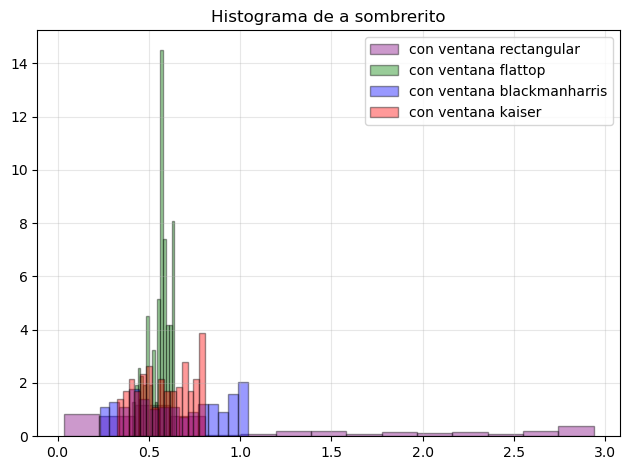

In [125]:
plt.hist(a1_sombrerito_rect, bins= 15, density=True, color='purple', alpha=0.4, edgecolor='black', label='con ventana rectangular')
plt.hist(a1_sombrerito_flattop, bins= 15, density=True, color='green', alpha=0.4, edgecolor='black', label='con ventana flattop')
plt.hist(a1_sombrerito_blackman, bins= 15, density=True, color='blue', alpha=0.4, edgecolor='black', label='con ventana blackmanharris')
plt.hist(a1_sombrerito_kaiser, bins= 15, density=True, color='red', alpha=0.4, edgecolor='black', label='con ventana kaiser')
plt.title('Histograma de a sombrerito')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Veremos que el ancho del histograma varía dependiendo del tipo de ventana elegida. Esto se debe a que, como vimos mas arriba, las ventanas que generan una mayor atenuacion de los lóbulos laterales y que logran ensanchar en mayor medida el ancho del lóbulo principal son a su vez las que generan mayor atenuacion en la amplitud de la señal. Esto implica que en la ventana con mayor atenuacion (en nuestro caso es flattop) tiene un rango de amplitudes mucho mas reducido, lo que se puede notar fácilmente en el histograma.

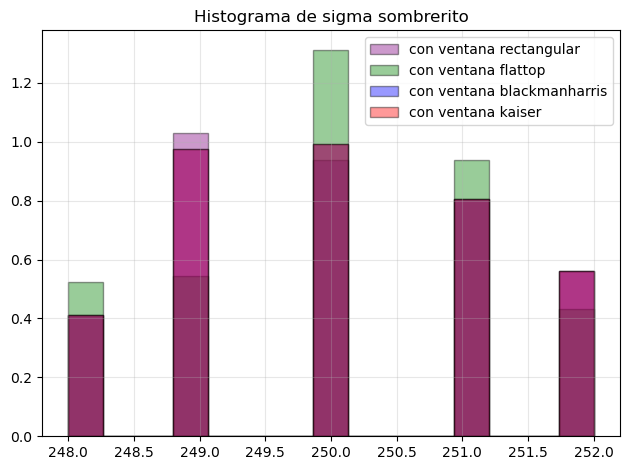

In [69]:
plt.hist(sigma1_sombrerito_rect, bins= 15, density=True, color='purple', alpha=0.4, edgecolor='black', label='con ventana rectangular')
plt.hist(sigma1_sombrerito_flattop, bins= 15, density=True, color='green', alpha=0.4, edgecolor='black', label='con ventana flattop')
plt.hist(sigma1_sombrerito_blackman, bins= 15, density=True, color='blue', alpha=0.4, edgecolor='black', label='con ventana blackmanharris')
plt.hist(sigma1_sombrerito_kaiser, bins= 15, density=True, color='red', alpha=0.4, edgecolor='black', label='con ventana kaiser')
plt.title('Histograma de sigma sombrerito')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Podemos notar como los valores de la frecuencia parecieran ser curvos con un pico en 250 Hz aproximadamente, lo cual no tendría sentido teniendo en cuenta como se hizo la construccion de fr y que esta variable es uniforme. La razón de esto es debido a que los valores de la frecuencia varían exactamente desde 248Hz hasta 252 Hz. Es por esto que en los extremos los valores son de aproximadamente la mitad (ya que, por aproximación, las frecuencias que se encuentran en ese punto son las que van de 248 a 248.5Hz y 251.5 a 252 Hz, mientras que en las frecuencias del medio estas frecuencias son de 248.5 a 249.5, 249.5 a 250.5 y 250.5 a 251.5, que es el doble de posibles frecuencias).

## Bonus 2: Analice el efecto del zero-padding para el estimador Ω^1

In [130]:
M = N*10

EspectroX_rect = np.fft.fft(x * w_rect, M)/N
EspectroX_flattop = np.fft.fft(x * w_flattop, M)/N
EspectroX_blackman = np.fft.fft(x * w_blackmanharris, M)/N
EspectroX_kaiser = np.fft.fft(x * w_kaiser, M)/N

EspectroX = EspectroX_rect.T

Mod_EspectroX = 2 * (np.abs(EspectroX))

mitad = len(EspectroX) // 2
primera_mitad_rect = EspectroX_rect[:, :mitad]
primera_mitad_flattop = EspectroX_flattop[:, :mitad]
primera_mitad_blackman = EspectroX_blackman[:, :mitad]
primera_mitad_kaiser = EspectroX_kaiser[:, :mitad]

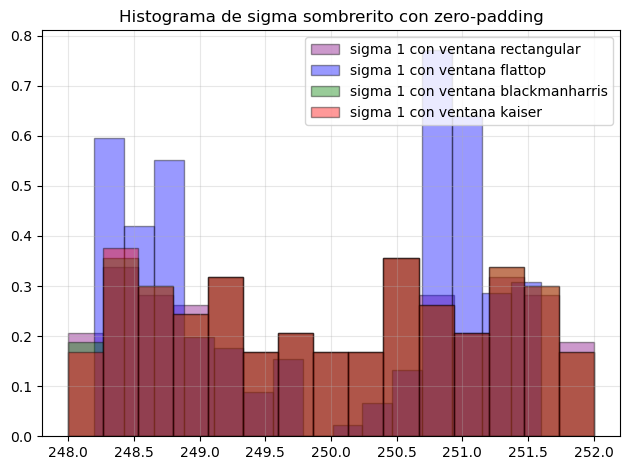

In [132]:
sigma1_sombrerito_rect = np.argmax(2 * np.abs(primera_mitad_rect), axis = 1)/(M/N)
sigma1_sombrerito_flattop = np.argmax(2 * np.abs(primera_mitad_flattop), axis = 1)/(M/N)
sigma1_sombrerito_blackman = np.argmax(2 * np.abs(primera_mitad_blackman), axis = 1)/(M/N)
sigma1_sombrerito_kaiser = np.argmax(2 * np.abs(primera_mitad_kaiser), axis = 1)/(M/N)

plt.hist(sigma1_sombrerito_rect, bins= 15, density=True, color='purple', alpha=0.4, edgecolor='black', label='sigma 1 con ventana rectangular')
plt.hist(sigma1_sombrerito_flattop, bins= 15, density=True, color='blue', alpha=0.4, edgecolor='black', label='sigma 1 con ventana flattop')
plt.hist(sigma1_sombrerito_blackman, bins= 15, density=True, color='green', alpha=0.4, edgecolor='black', label='sigma 1 con ventana blackmanharris')
plt.hist(sigma1_sombrerito_kaiser, bins= 15, density=True, color='red', alpha=0.4, edgecolor='black', label='sigma 1 con ventana kaiser')

plt.title('Histograma de sigma sombrerito con zero-padding')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Viendo estos resultados podemos entender los valores del histograma de arriba, ya que nos permite ver de manera muy clara el hecho de que las frecuencias se distribuyen a lo largo de todos los valores de frecuencias (no por los bins), lo que lleva a que hayan resultados que parecen no tener sentido y se deben unicamente a la manera de realizar el analisis de la señal.

In [133]:
sesgo_sigma1_rect = np.mean(sigma1_sombrerito_rect) - sigma0
varianza_sigma1_rect = np.var(sigma1_sombrerito_rect)
sesgo_sigma1_flattop = np.mean(sigma1_sombrerito_flattop) - sigma0
varianza_sigma1_flattop = np.var(sigma1_sombrerito_flattop)
sesgo_sigma1_blackman = np.mean(sigma1_sombrerito_blackman) - sigma0
varianza_sigma1_blackman = np.var(sigma1_sombrerito_blackman)
sesgo_sigma1_kaiser = np.mean(sigma1_sombrerito_kaiser) - sigma0
varianza_sigma1_kaiser = np.var(sigma1_sombrerito_kaiser)

print('Estimación de frecuencia con zero-padding:')
print('Ventana \t sesgo \t varianza')
print(f'Rectangular \t {sesgo_sigma1_rect:.2f} \t {varianza_sigma1_rect:.3f}')
print(f'Flattop \t {sesgo_sigma1_flattop:.2f} \t {varianza_sigma1_flattop:.3f}')
print(f'Blackmanharris \t {sesgo_sigma1_blackman:.2f} \t {varianza_sigma1_blackman:.3f}')
print(f'Kaiser \t\t {sesgo_sigma1_kaiser:.2f} \t {varianza_sigma1_kaiser:.3f}')

Estimación de frecuencia con zero-padding:
Ventana 	 sesgo 	 varianza
Rectangular 	 -0.03 	 1.364
Flattop 	 -0.13 	 1.390
Blackmanharris 	 -0.03 	 1.360
Kaiser 		 -0.03 	 1.357


Los resultados de la varianza del estimador de frecuencia fueron reducidos en todas las ventanas utilizadas con respecto al estimador sin el zero-padding. Esto es congruente con lo visto en el histograma ya que los valores son mas regulares a lo largo de las distintas frecuencias. Esta disminución en la varianza se debe a que al hacer zero-padding se reduce un error ya mencionado anteriormente, y se debe a que al tomar artificialmente más bins las aproximaciones a estos no son tan amplias, por lo que, aunque los bins de los extremos tengan menos energía con respecto a los otros, esta está más repartida generando un resultado mas uniforme.